In [ ]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [123]:
# Load the merged data from Excel
df = pd.read_excel("merged_data.xlsx", sheet_name="Sheet1")
print(df.head())
print(df.info())

  Year_Month      India     Brazil  Spot_Price  Year  Month
0 2002-01-01  57.541961  58.503052       19.42  2002      1
1 2002-02-01  57.418721  58.713680       20.28  2002      2
2 2002-03-01  57.665144  59.065903       23.70  2002      3
3 2002-04-01  57.788385  59.538530       25.73  2002      4
4 2002-05-01  58.158048  59.663430       25.35  2002      5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Year_Month  283 non-null    datetime64[ns]
 1   India       283 non-null    float64       
 2   Brazil      283 non-null    float64       
 3   Spot_Price  283 non-null    float64       
 4   Year        283 non-null    int64         
 5   Month       283 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 13.4 KB
None


In [124]:
# Basic descriptive statistics
print(df[["Brazil", "India", "Spot_Price"]].describe(), "\n")
print(df[["Brazil", "India", "Spot_Price"]].skew(), "\n")
print(df[["Brazil", "India", "Spot_Price"]].kurtosis(), "\n")

           Brazil       India  Spot_Price
count  283.000000  283.000000  283.000000
mean   132.100681  132.264882   70.226890
std     50.069748   54.930392   26.975779
min     58.503052   57.418721   18.380000
25%     87.384214   76.172430   49.885000
50%    120.735109  135.453064   69.080000
75%    167.888201  173.370383   86.970000
max    235.414037  234.658125  132.720000 

Brazil        0.435066
India         0.216027
Spot_Price    0.185087
dtype: float64 

Brazil       -0.996557
India        -1.215316
Spot_Price   -0.767998
dtype: float64 



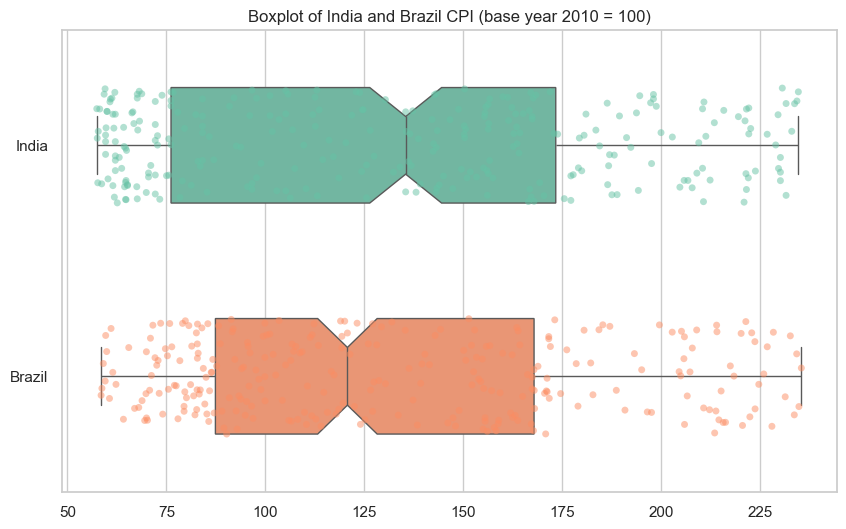

In [136]:
# Boxplot visualization for India and Brazil CPI Monthly data
plt.figure(figsize=(10, 6))
sns.stripplot(data=df[["India", "Brazil"]], orient="h", palette="Set2", size=5, jitter=0.25, alpha=0.5)
sns.boxplot(data=df[["India", "Brazil"]], palette="Set2", width=0.5, fliersize=5, linewidth=1, notch=True, orient="h")
plt.title("Boxplot of India and Brazil CPI (base year 2010 = 100)")
plt.show()

/var/folders/q2/mtjqjllx1gd3d313l6v2m63c0000gn/T/ipykernel_11312/4240650542.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df["Spot_Price"], orient="h", palette="Set1", size=5, jitter=0.25, alpha=0.5)
/var/folders/q2/mtjqjllx1gd3d313l6v2m63c0000gn/T/ipykernel_11312/4240650542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df["Spot_Price"], palette="Set1", width=0.3, fliersize=5, linewidth=1, notch = True, orient="h")


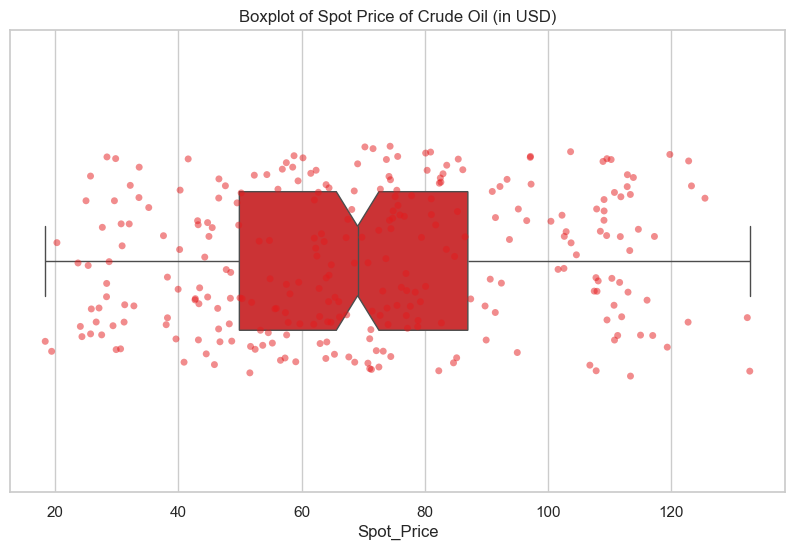

In [126]:
# Boxplot visualization for Spot Price of Crude Oil data 
plt.figure(figsize=(10, 6))
sns.stripplot(data=df["Spot_Price"], orient="h", palette="Set1", size=5, jitter=0.25, alpha=0.5)
sns.boxplot(data=df["Spot_Price"], palette="Set1", width=0.3, fliersize=5, linewidth=1, notch = True, orient="h")
plt.title("Boxplot of Spot Price of Crude Oil (in USD)")
plt.show()

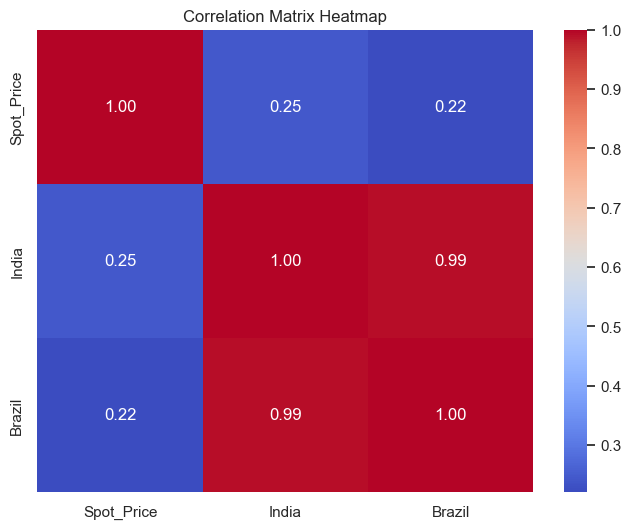

In [127]:
# Correlation matrix and heatmap
corrl = df[["Spot_Price", "India", "Brazil"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corrl, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [128]:
print("Average Spot Price by Year =\n", df.groupby("Year")["Spot_Price"].mean(), "\n")

Average Spot Price by Year =
 Year
2002     24.963333
2003     28.882500
2004     38.230000
2005     54.418333
2006     65.146667
2007     72.465000
2008     96.847500
2009     61.490000
2010     79.511667
2011    111.264167
2012    111.651667
2013    108.637500
2014     99.023333
2015     52.353333
2016     43.548333
2017     54.247500
2018     71.060833
2019     64.358333
2020     41.759167
2021     70.677500
2022    100.777500
2023     82.468333
2024     80.526667
2025     71.785714
Name: Spot_Price, dtype: float64 



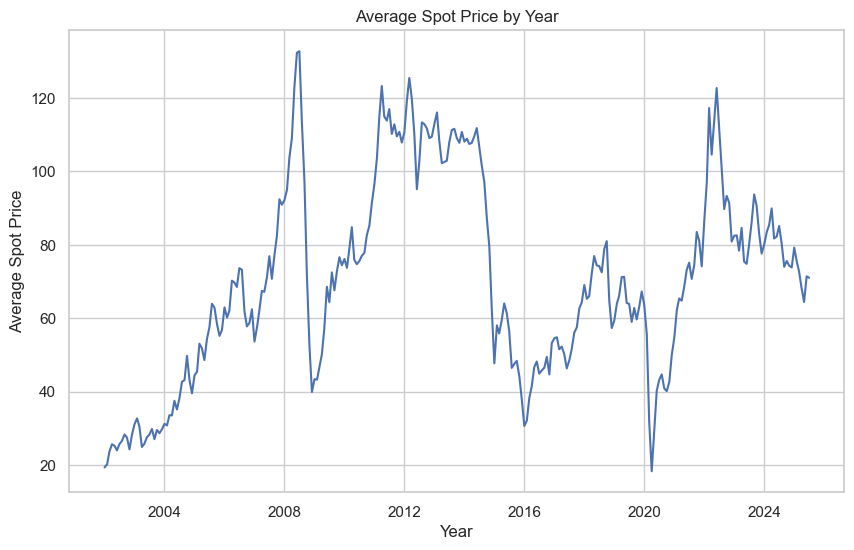

In [129]:
# Line plot of Spot Price by Month
plt.figure(figsize=(10, 6))
plt.title("Average Spot Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Spot Price")
sns.lineplot(data=df, x="Year_Month", y="Spot_Price")
plt.show()

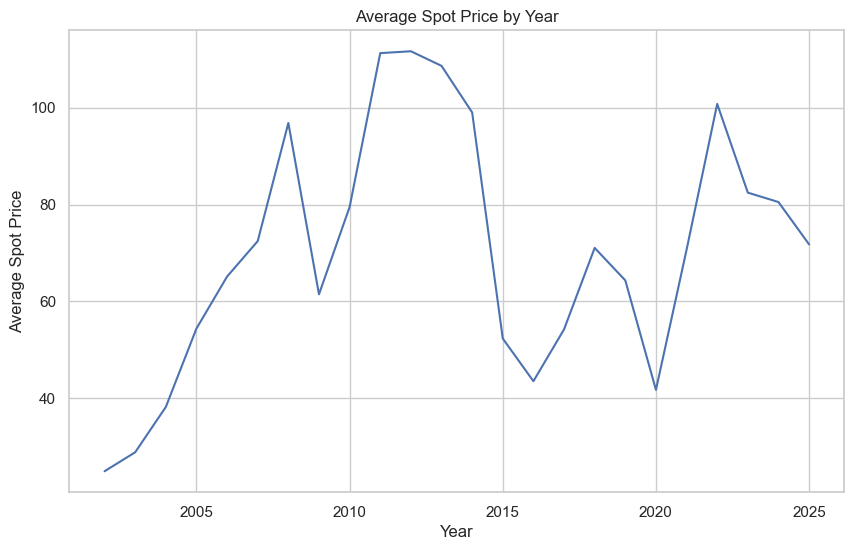

In [130]:
# Line plot of Average Spot Price by Year
plt.figure(figsize=(10, 6))
plt.title("Average Spot Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Spot Price")
sns.lineplot(data=df, x="Year", y="Spot_Price", errorbar=None)
plt.show()

In [131]:
# Basic outlier event check using Inter-Quartile Range
Q1 = df["Spot_Price"].quantile([0.25, 0.5, 0.75])[0.25]
Q3 = df["Spot_Price"].quantile([0.25, 0.5, 0.75])[0.75]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(lower_bound)
print(upper_bound)
outliers = df[(df["Spot_Price"] <= lower_bound) | (df["Spot_Price"] >= upper_bound)]
print("Outliers in Spot Price = \n", outliers)

-5.7424999999999855
142.5975
Outliers in Spot Price = 
 Empty DataFrame
Columns: [Year_Month, India, Brazil, Spot_Price, Year, Month]
Index: []


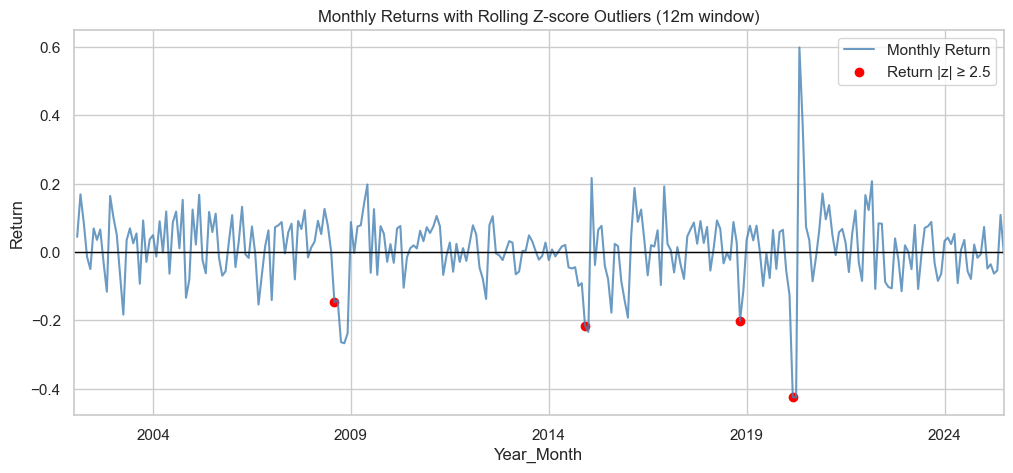

Largest down moves = 
Year_Month
2020-04-01   -0.425804
2020-03-01   -0.424901
2008-11-01   -0.267253
2008-10-01   -0.263807
2008-12-01   -0.238322
Name: Spot_Price, dtype: float64
Largest up moves = 
Year_Month
2020-05-01    0.598477
2020-06-01    0.370660
2015-02-01    0.216499
2022-03-01    0.207145
2009-06-01    0.197382
Name: Spot_Price, dtype: float64


In [132]:
# More robust outlier event check using monthly returns and rolling z score method
s = df.set_index("Year_Month")["Spot_Price"]
r = s.pct_change()  # monthly returns
r_z = (r - r.rolling(12, min_periods=6).mean()) / r.rolling(12, min_periods=6).std()

fig, ax = plt.subplots(figsize=(12,5))
r.plot(ax=ax, color = "steelblue", alpha=0.8, label="Monthly Return")
ax.axhline(0, color = "black", linewidth=1)
ax.scatter(r.index[abs(r_z) >= 2.5], r[abs(r_z) >= 2.5], color="red", label="Return |z| ≥ 2.5")
ax.set_title("Monthly Returns with Rolling Z-score Outliers (12m window)")
ax.set_ylabel("Return")
ax.legend()
plt.show()

print("Largest down moves = ")
print(r.sort_values().head(5))

print("Largest up moves = ")
print(r.sort_values(ascending=False).head(5))

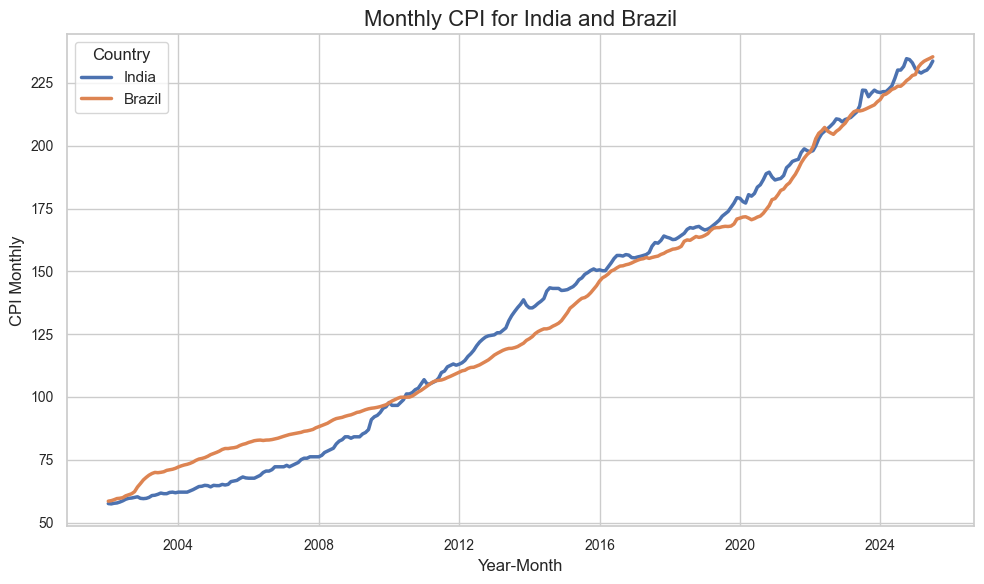

In [133]:
# Line plot of CPI of India by Month
sns.set_theme(style="whitegrid", palette="deep")
plt.figure(figsize=(10, 6))
plt.title("Monthly CPI for India and Brazil", fontsize=16)
sns.lineplot(data=df,x="Year_Month",y="India",label="India",
            errorbar=None,linewidth=2.5)
sns.lineplot(data=df,x="Year_Month",y="Brazil",label="Brazil",
            errorbar=None,linewidth=2.5)

plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("CPI Monthly", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Country", loc="upper left")
plt.tight_layout()
plt.show()

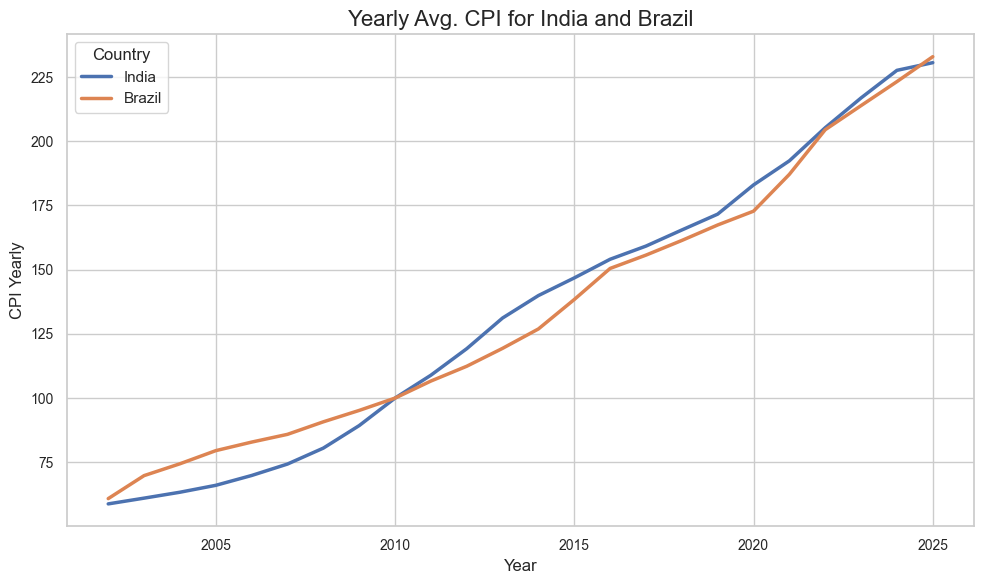

In [134]:
# Line plot of Average CPI of India by Year
sns.set_theme(style="whitegrid", palette="deep")
plt.figure(figsize=(10, 6))
plt.title("Yearly Avg. CPI for India and Brazil", fontsize=16)
sns.lineplot(data=df,x="Year",y="India",label="India",
            errorbar=None,linewidth=2.5)
sns.lineplot(data=df,x="Year",y="Brazil",label="Brazil",
            errorbar=None,linewidth=2.5)

plt.xlabel("Year", fontsize=12)
plt.ylabel("CPI Yearly", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Country", loc="upper left")
plt.tight_layout()
plt.show()